### import library

In [ ]:
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt

### Define dataset

In [ ]:
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
!tar -xvzf images.tar.gz
!tar -xvzf annotations.tar.gz

In [ ]:
!mkdir -p data/OxfordPets/images
!mkdir -p data/OxfordPets/masks
!cp images/* data/OxfordPets/images/
!cp annotations/trimaps/* data/OxfordPets/masks/

In [ ]:
class OxfordPetsDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None, size=(128, 128)):
        self.image_dir = image_dir
        self.mask_dir = mask_dir

        self.image_list = sorted([
            f for f in os.listdir(image_dir) if f.endswith('.jpg')
        ])
        self.mask_list = sorted([
            f for f in os.listdir(mask_dir) if f.endswith('.png')
        ])

        # Ensure both lists are aligned by filename prefix
        self.image_list = [f for f in self.image_list if f.replace('.jpg', '.png') in self.mask_list]
        self.mask_list = [f.replace('.jpg', '.png') for f in self.image_list]

        self.size = size
        self.transform = transform

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_list[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_list[idx])

        image = Image.open(img_path).convert('RGB')
        mask = Image.open(mask_path)

        image = image.resize(self.size)
        mask = mask.resize(self.size, Image.NEAREST)

        mask_np = np.array(mask)
        mask_np = np.where(mask_np == 1, 1, 0)  # Binary: pet = 1, else = 0

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(mask_np, dtype=torch.long)

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = OxfordPetsDataset(
    image_dir='./data/OxfordPets/images',
    mask_dir='./data/OxfordPets/masks',
    transform=transform
)

test_dataset = OxfordPetsDataset(
    image_dir='./data/OxfordPets/images',
    mask_dir='./data/OxfordPets/masks',
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False)

### Define model

In [ ]:

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv_block(x)

class Encoder(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.encoder = nn.Sequential(
            ConvBlock(in_channels, out_channels),
            nn.MaxPool2d(2)
        )

    def forward(self, x):
        return self.encoder(x)

class Decoder(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up_sample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.refinement = ConvBlock(in_channels, out_channels)

    def forward(self, x, skip):
        x = self.up_sample(x)
        x = torch.cat([x, skip], dim=1)
        return self.refinement(x)

class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=1):
        super().__init__()
        self.in_conv = ConvBlock(n_channels, 64)
        self.enc1 = Encoder(64, 128)
        self.enc2 = Encoder(128, 256)
        self.enc3 = Encoder(256, 512)
        self.enc4 = Encoder(512, 1024)

        self.dec1 = Decoder(1024 + 512, 512)
        self.dec2 = Decoder(512 + 256, 256)
        self.dec3 = Decoder(256 + 128, 128)
        self.dec4 = Decoder(128 + 64, 64)

        self.out_conv = nn.Conv2d(64, n_classes, kernel_size=1)

    def forward(self, x):
        x1 = self.in_conv(x)
        x2 = self.enc1(x1)
        x3 = self.enc2(x2)
        x4 = self.enc3(x3)
        x5 = self.enc4(x4)

        d1 = self.dec1(x5, x4)
        d2 = self.dec2(d1, x3)
        d3 = self.dec3(d2, x2)
        d4 = self.dec4(d3, x1)

        return torch.sigmoid(self.out_conv(d4))

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
model = UNet(3, 1).to(device)

### Train

In [ ]:
def compute_metrics(preds, labels):
    with torch.no_grad():
        preds = (preds > 0.5).float()
        pixel_acc = (preds == labels).float().mean().item()

        intersection = (preds * labels).sum().float()
        union = (preds + labels).sum().float() - intersection
        dice = (2. * intersection) / (preds.sum() + labels.sum() + 1e-6)
        iou = intersection / (union + 1e-6)

        return pixel_acc, iou.item(), dice.item()

In [ ]:
epochs = 30
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

history = {'loss': [], 'acc': [], 'iou': [], 'dice': []}

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs.squeeze(1), targets.float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {total_loss / len(train_loader):.4f}")
    history['loss'].append(total_loss / len(train_loader))

    model.eval()
    total_acc, total_iou, total_dice = 0, 0, 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            acc, iou, dice = compute_metrics(outputs.squeeze(1), targets.float())
            total_acc += acc
            total_iou += iou
            total_dice += dice

    epoch_acc = total_acc / len(test_loader)
    epoch_iou = total_iou / len(test_loader)
    epoch_dice = total_dice / len(test_loader)

    history['acc'].append(epoch_acc)
    history['iou'].append(epoch_iou)
    history['dice'].append(epoch_dice)

    print(f"\nValidation Metrics after Epoch {epoch+1}:")
    print(f"Pixel Accuracy: {total_acc / len(test_loader):.4f}")
    print(f"Mean IoU: {total_iou / len(test_loader):.4f}")
    print(f"Mean Dice: {total_dice / len(test_loader):.4f}\n")

Epoch 1/30 | Train Loss: 0.4335

Validation Metrics after Epoch 1:
Pixel Accuracy: 0.8316
Mean IoU: 0.4946
Mean Dice: 0.6498

Epoch 2/30 | Train Loss: 0.3337

Validation Metrics after Epoch 2:
Pixel Accuracy: 0.8874
Mean IoU: 0.6672
Mean Dice: 0.7929

Epoch 3/30 | Train Loss: 0.2723

Validation Metrics after Epoch 3:
Pixel Accuracy: 0.8762
Mean IoU: 0.6805
Mean Dice: 0.7997

Epoch 4/30 | Train Loss: 0.2378

Validation Metrics after Epoch 4:
Pixel Accuracy: 0.9069
Mean IoU: 0.7315
Mean Dice: 0.8378

Epoch 5/30 | Train Loss: 0.2109

Validation Metrics after Epoch 5:
Pixel Accuracy: 0.9182
Mean IoU: 0.7546
Mean Dice: 0.8544

Epoch 6/30 | Train Loss: 0.1916

Validation Metrics after Epoch 6:
Pixel Accuracy: 0.9124
Mean IoU: 0.7467
Mean Dice: 0.8471

Epoch 7/30 | Train Loss: 0.1753

Validation Metrics after Epoch 7:
Pixel Accuracy: 0.9264
Mean IoU: 0.7581
Mean Dice: 0.8561

Epoch 8/30 | Train Loss: 0.1640

Validation Metrics after Epoch 8:
Pixel Accuracy: 0.9341
Mean IoU: 0.7868
Mean Dice: 

### Plot metrics

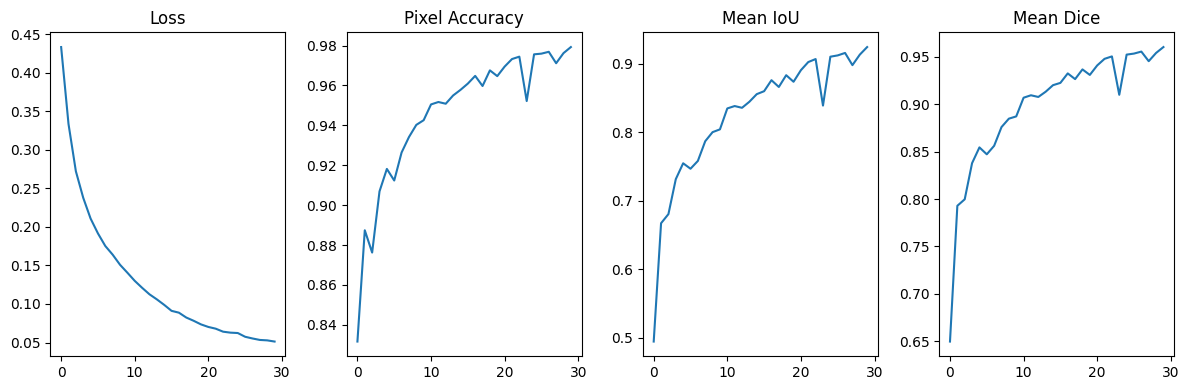

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1)
plt.plot(history['loss'], label='Loss')
plt.title('Loss')
plt.subplot(1, 4, 2)
plt.plot(history['acc'], label='Pixel Acc')
plt.title('Pixel Accuracy')
plt.subplot(1, 4, 3)
plt.plot(history['iou'], label='IoU')
plt.title('Mean IoU')
plt.subplot(1, 4, 4)
plt.plot(history['dice'], label='Dice')
plt.title('Mean Dice')
plt.tight_layout()
plt.show()

### Run sample

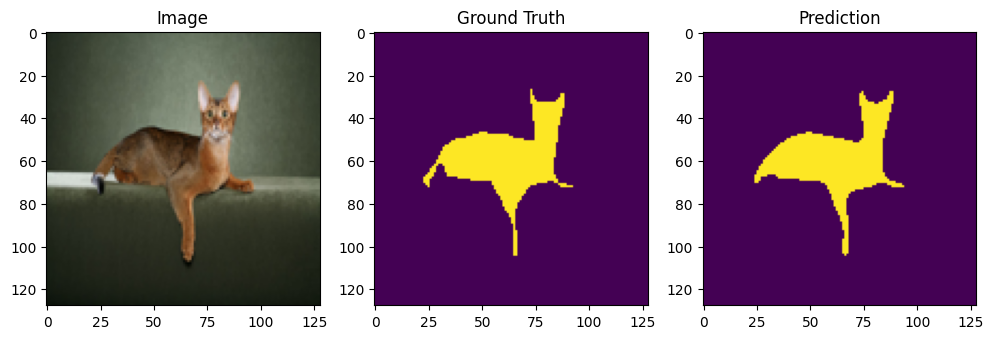

In [ ]:
# Sample Prediction
model.eval()
sample_img, sample_mask = test_dataset[0]
sample_img_tensor = sample_img.unsqueeze(0).to(device)

with torch.no_grad():
    sample_pred = model(sample_img_tensor)
    sample_pred = (sample_pred.squeeze().cpu().numpy() > 0.5).astype(np.uint8)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(sample_img.permute(1, 2, 0))
plt.title('Image')
plt.subplot(1, 3, 2)
plt.imshow(sample_mask.numpy())
plt.title('Ground Truth')
plt.subplot(1, 3, 3)
plt.imshow(sample_pred)
plt.title('Prediction')
plt.show()

In [ ]:
torch.save(model.state_dict(), 'best.pth')